1. Linear Kernel

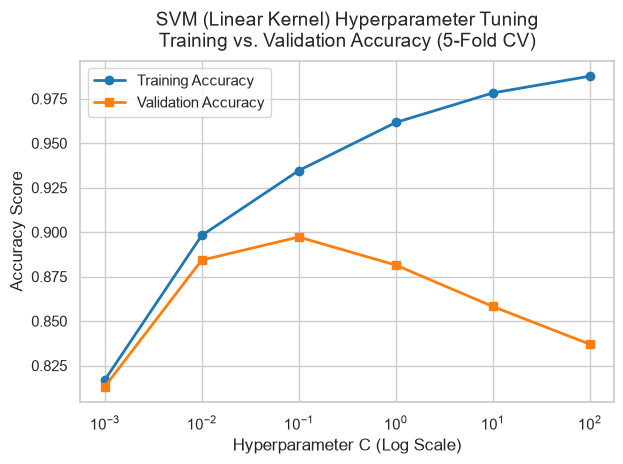

Optimal C value found: 0.1
Best Validation Accuracy: 0.8973


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

# 1. Load the preprocessed dataset
df = pd.read_csv('df_EDA_minmax.csv')

# Separate features (X) and target (y)
# Drop SalePrice to prevent deterministic data leakage
X = df.drop(columns=['SalePrice', 'Price_Category'], errors='ignore')
y = df['Price_Category']

# 2. Set up the range for hyperparameter C (logarithmic spacing)
c_values = [0.001, 0.01, 0.1, 1, 10, 100]
param_grid = {'C': c_values}

# 3. Initialize Linear SVM and GridSearchCV
# Using 5 folds and returning training scores to plot the evaluation curve
svm_model = SVC(kernel='linear', random_state=42)
grid_search = GridSearchCV(svm_model, param_grid, cv=5, return_train_score=True, n_jobs=-1)
grid_search.fit(X, y)

# 4. Extract cross-validation scores
results = grid_search.cv_results_
train_accuracies = results['mean_train_score']
val_accuracies = results['mean_test_score']

# 5. Plot Training vs. Validation Accuracies
plt.rc('font', size=11)
sns.set_theme(style='whitegrid')

plt.plot(c_values, train_accuracies, marker='o', label='Training Accuracy', color='#1f77b4', linewidth=2)
plt.plot(c_values, val_accuracies, marker='s', label='Validation Accuracy', color='#ff7f0e', linewidth=2)

# Use log-scale since C spans multiple orders of magnitude
plt.xscale('log')
plt.xlabel('Hyperparameter C (Log Scale)', fontsize=12)
plt.ylabel('Accuracy Score', fontsize=12)
plt.title('SVM (Linear Kernel) Hyperparameter Tuning\nTraining vs. Validation Accuracy (5-Fold CV)', fontsize=14, pad=10)
plt.legend(frameon=True)
plt.tight_layout()

# Save the validation curve plot
plt.show()

print(f"Optimal C value found: {grid_search.best_params_['C']}")
print(f"Best Validation Accuracy: {grid_search.best_score_:.4f}")

2. RBF Kerner

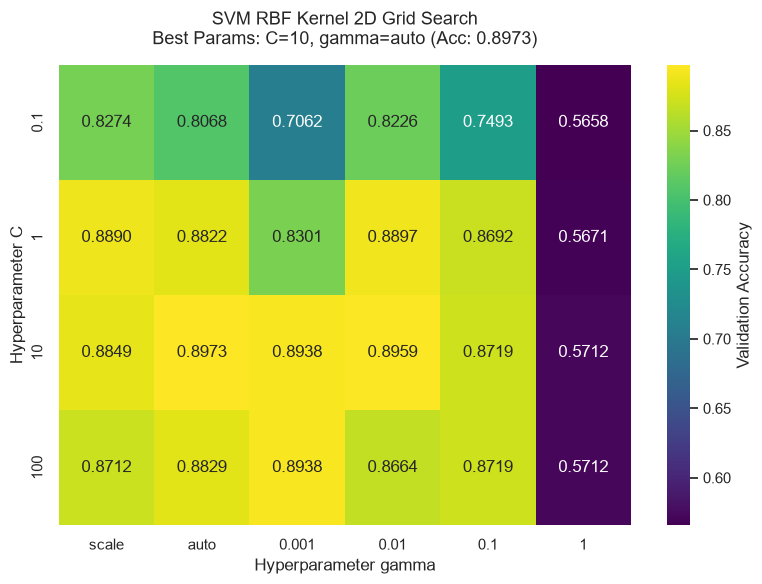

Grid Search Complete. Best Accuracy: 0.8973


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

# 1. Load the preprocessed dataset
df = pd.read_csv('df_EDA_minmax.csv')

# Separate features (X) and target (y) while discarding SalePrice to avoid leakage
X = df.drop(columns=['SalePrice', 'Price_Category'], errors='ignore')
y = df['Price_Category']

# 2. Define the hyperparameter combinations
c_values = [0.1, 1, 10, 100]
gamma_values = ['scale', 'auto', 0.001, 0.01, 0.1, 1]

param_grid = {
    'C': c_values,
    'gamma': gamma_values
}

# 3. Execute simultaneous 5-Fold Cross Validation Grid Search
svm_rbf = SVC(kernel='rbf', random_state=42)
grid_search = GridSearchCV(svm_rbf, param_grid, cv=5, return_train_score=True, n_jobs=-1)
grid_search.fit(X, y)

# 4. Extract performance matrices
results = grid_search.cv_results_
best_params = grid_search.best_params_
best_score = grid_search.best_score_

# Reshape 1D test score list into a 2D matrix matching the grid shape
scores_matrix = results['mean_test_score'].reshape(len(c_values), len(gamma_values))

# 5. Generate Landscape Heatmap
plt.rc('font', size=11)
sns.set_theme(style='white')

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    scores_matrix, 
    annot=True, 
    fmt=".4f", 
    xticklabels=gamma_values, 
    yticklabels=c_values, 
    cmap='viridis', 
    ax=ax,
    cbar_kws={'label': 'Validation Accuracy'}
)

ax.set_xlabel('Hyperparameter gamma', fontsize=12)
ax.set_ylabel('Hyperparameter C', fontsize=12)
ax.set_title(f'SVM RBF Kernel 2D Grid Search\nBest Params: C={best_params["C"]}, gamma={best_params["gamma"]} (Acc: {best_score:.4f})', fontsize=13, pad=15)
plt.tight_layout()

# Save the matrix image locally
plt.show()

print(f"Grid Search Complete. Best Accuracy: {best_score:.4f}")


In [5]:
print(best_params)

{'C': 10, 'gamma': 'auto'}


The exact numerical value of your optimal gamma ('auto' ) is 1/224, which calculates out precisely to: 0.004464285714